# Ejercicio Regression Tree
Son datos de temperaturas tomados de la ciudad de Seattle. El objetivo es intentar predecir lo mejor posible la máxima temperatura (columna `actual`) que alcanzaremos al día siguiente. Para ello contaremos con temperaturas de los dos días anteriores, históricos de máximas temperaturas y un amigo bastante chapas que te da su predicción del tiempo cada día.

**Resumen de datos**:
* year: 2016 for all data points
* month: number for month of the year
* day: number for day of the year
* week: day of the week as a character string
* temp_2: max temperature 2 days prior
* temp_1: max temperature 1 day prior
* average: historical average max temperature
* actual: max temperature measurement
* friend: your friend’s prediction, a random number between 20 below the average and 20 above the average


### 1. Importa el csv "temps.csv"

In [11]:
import pandas as pd

In [12]:
seattle = pd.read_csv (r'data\temps.csv')

### 2. Realiza un análisis exploratorio junto con un Feature Engineering

In [13]:
seattle.info()
# no hay nulos pero week está en string

<class 'pandas.DataFrame'>
RangeIndex: 348 entries, 0 to 347
Data columns (total 9 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   year     348 non-null    int64  
 1   month    348 non-null    int64  
 2   day      348 non-null    int64  
 3   week     348 non-null    str    
 4   temp_2   348 non-null    int64  
 5   temp_1   348 non-null    int64  
 6   average  348 non-null    float64
 7   actual   348 non-null    int64  
 8   friend   348 non-null    int64  
dtypes: float64(1), int64(7), str(1)
memory usage: 24.6 KB


In [14]:
seattle.head()

,year,month,day,week,temp_2,temp_1,average,actual,friend
0,2016,1,1,Fri,45,45,45.6,45,29
1,2016,1,2,Sat,44,45,45.7,44,61
2,2016,1,3,Sun,45,44,45.8,41,56
3,2016,1,4,Mon,44,41,45.9,40,53
4,2016,1,5,Tues,41,40,46.0,44,41


In [15]:
seattle.describe()

,year,month,day,temp_2,temp_1,average,actual,friend
count,348.0,348.000000,348.000000,348.000000,348.000000,348.000000,348.000000,348.000000
mean,2016.0,6.477011,15.514368,62.652299,62.701149,59.760632,62.543103,60.034483
std,0.0,3.498380,8.772982,12.165398,12.120542,10.527306,11.794146,15.626179
min,2016.0,1.000000,1.000000,35.000000,35.000000,45.100000,35.000000,28.000000
25%,2016.0,3.000000,8.000000,54.000000,54.000000,49.975000,54.000000,47.750000
50%,2016.0,6.000000,15.000000,62.500000,62.500000,58.200000,62.500000,60.000000
75%,2016.0,10.000000,23.000000,71.000000,71.000000,69.025000,71.000000,71.000000
max,2016.0,12.000000,31.000000,117.000000,117.000000,77.400000,92.000000,95.000000


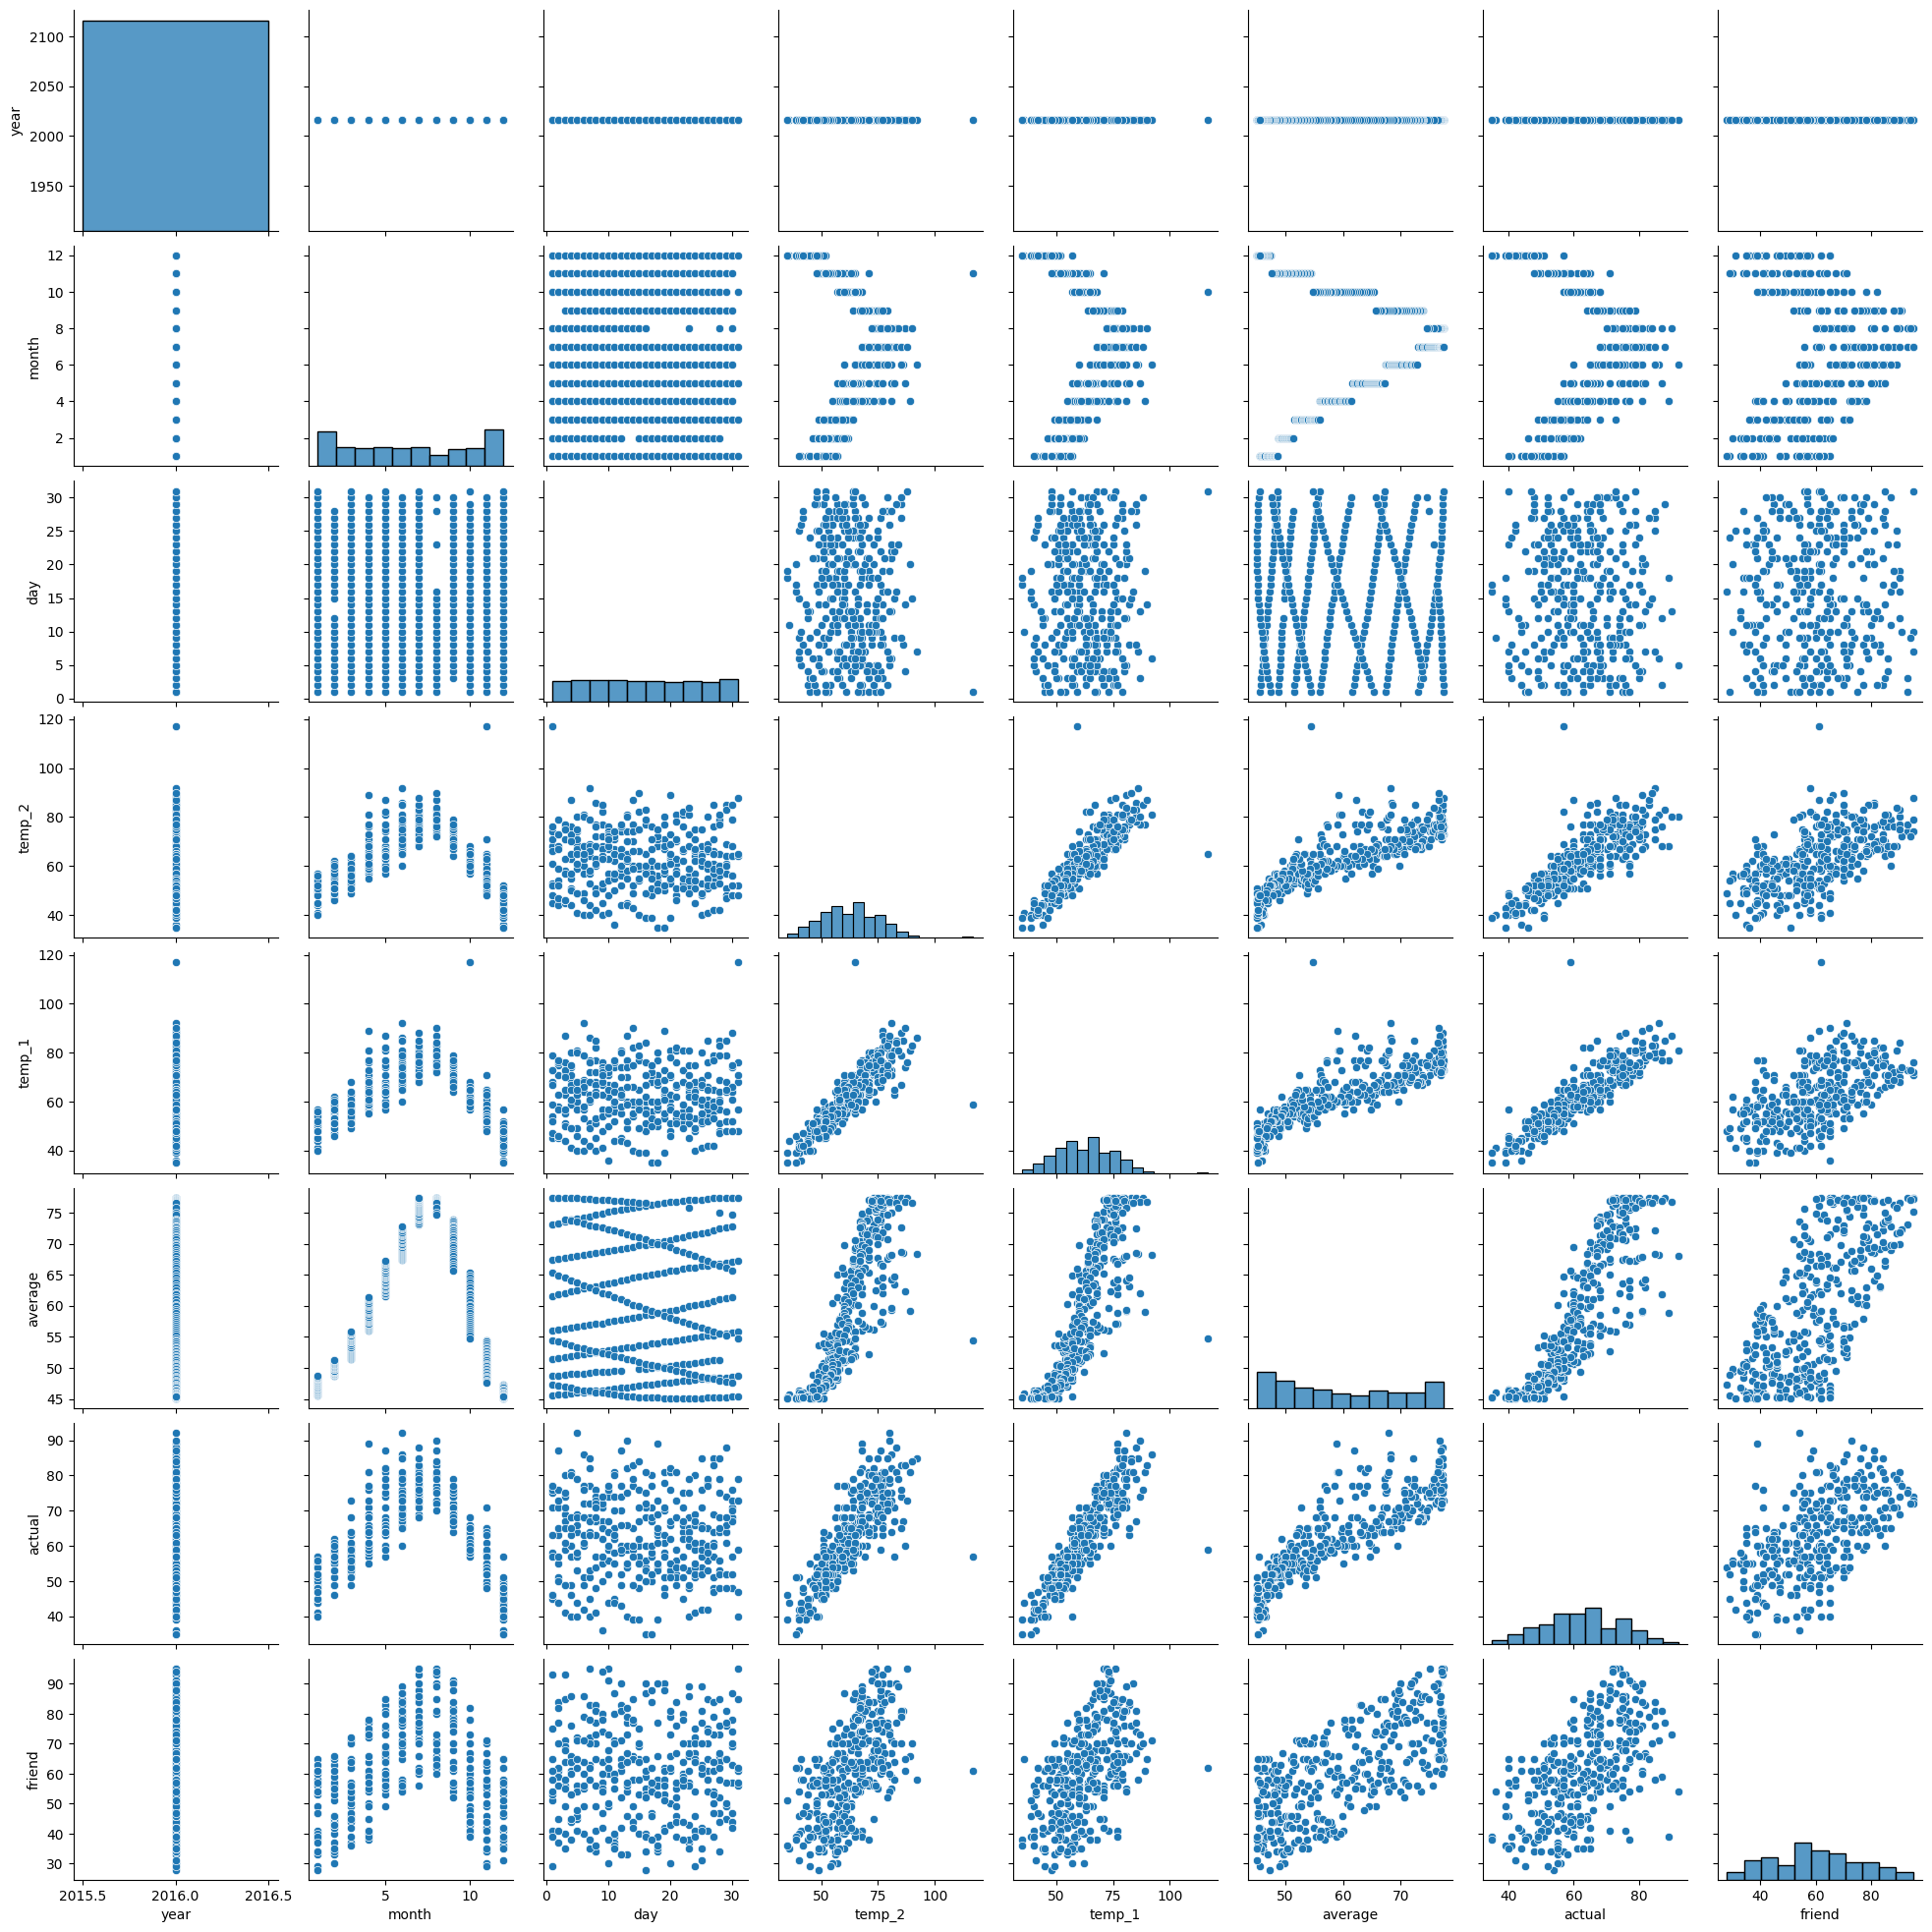

In [16]:
import seaborn as sns
sns.pairplot (seattle)

<Axes: >

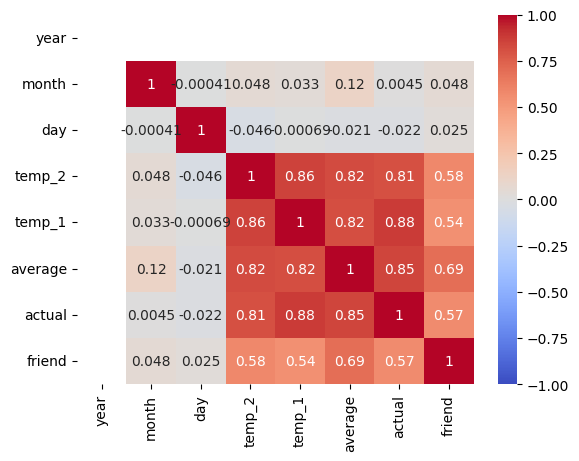

In [17]:
sns.heatmap (seattle.corr(numeric_only=True), annot=True, vmin=-1,vmax=1, cmap='coolwarm')

In [18]:
#El año es 2016 toda la columna - no aporta valor
# El día de la semana además de estar en letra para la predicción de temperaturas no tiene ningún sentido
# Lo mismo con el día del mes. Y la predicción del amigo 
# Hay sin embargo varias variables que presentan colinealidad con actual: temp_1, temp_" y average. 
# Month no presenta colinealidad pero por conocimiento de negocio (y porque en un árbol de regresión no 
# se necesita que exista relación lineal

# Puede haber una correlación entre dos variables (helados - resfriados) pero no puedo inferir de ahí que haya causalidad. Eso sí, puedo usar el número de helados vendidos para
# predecir resfriados. 

### 3. Selecciona variables y divide en train y test

In [19]:
from sklearn.model_selection import train_test_split

# Al árbol de regresi´p
X = seattle [['month', 'temp_1','temp_2','average']]
y= seattle ['actual']

X_train, X_test, y_train, y_test = train_test_split (X, y, test_size=0.2, random_state=42)

In [20]:
print(X_train.shape)
print(X_test.shape)

(278, 4)
(70, 4)


### 4. Entrena el modelo


In [21]:
from sklearn.tree import DecisionTreeRegressor

tree_model = DecisionTreeRegressor(max_depth=2, random_state=42)
tree_model.fit (X_train, y_train)


,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",2
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf

### 5. Evaluación de tu modelo
Calcula el coeficiente de determinación. 

Calcula el MAE, MAPE, MSE y RMSE.

In [22]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_absolute_percentage_error, mean_squared_error

y_pred = tree_model.predict (X_test)

print("Train R2:", r2_score (y_train, tree_model.predict(X_train)))
print("Test R2:", r2_score (y_test, y_pred))
print("Train MSE:", mean_squared_error(y_train, tree_model.predict(X_train)))
print("Test MSE:", mean_squared_error(y_test, y_pred))
print("Train MAE:", mean_absolute_error (y_train, tree_model.predict(X_train)))
print("Test MAE:", mean_absolute_error (y_test, y_pred))
print("Train MAPE:", mean_absolute_percentage_error (y_train, tree_model.predict(X_train)))
print("Test MAPE:", mean_absolute_percentage_error (y_test, y_pred))



Train R2: 0.7929201827341514
Test R2: 0.7307506227036282
Train MSE: 28.62210750879816
Test MSE: 37.64787660374395
Train MAE: 4.191991861056609
Test MAE: 4.888811585240156
Train MAPE: 0.06815683252257974
Test MAPE: 0.07740495191086964


### 6. Representa el árbol de decisión

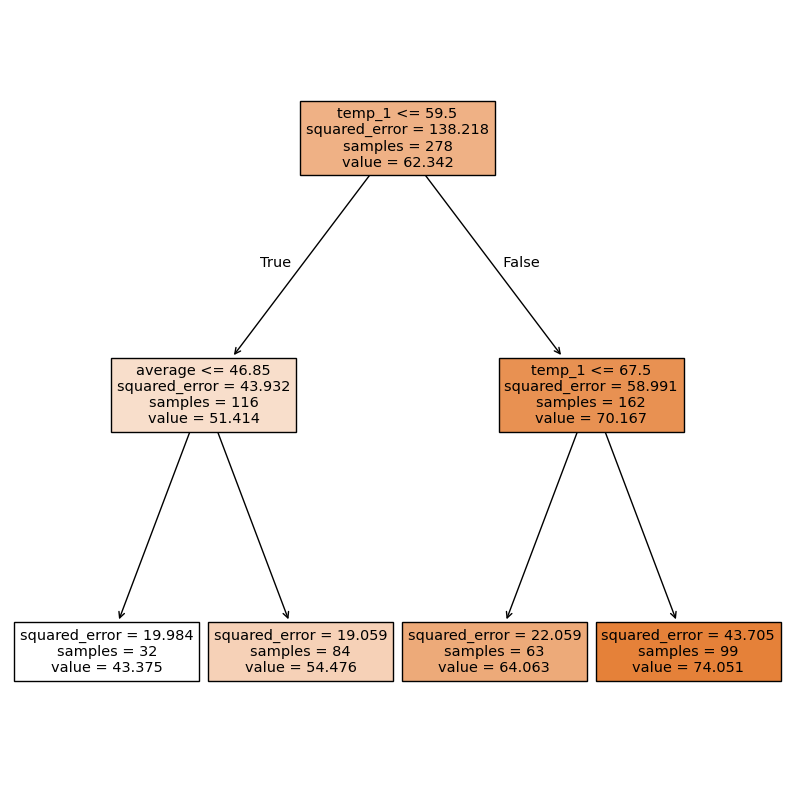

In [23]:
import matplotlib.pyplot as plt
import sklearn

plt.figure(figsize=(10,10))
sklearn.tree.plot_tree(tree_model,
               feature_names=['month', 'temp_1','temp_2','average'],
                class_names=None,
               filled = True);

### 7. Modifica el max_depth a 3 y vuelve a entrenarlo

In [24]:
tree_model3 = DecisionTreeRegressor(max_depth=3, random_state=42)
tree_model3.fit (X_train, y_train)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",3
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf

### 8. Vuelve a evaluar tu modelo

In [25]:
y_pred = tree_model3.predict (X_test)

print("Train R2:", r2_score (y_train, tree_model3.predict(X_train)))
print("Test R2:", r2_score (y_test, y_pred))
print("Train MSE:", mean_squared_error(y_train, tree_model3.predict(X_train)))
print("Test MSE:", mean_squared_error(y_test, y_pred))
print("Train MAE:", mean_absolute_error (y_train, tree_model3.predict(X_train)))
print("Test MAE:", mean_absolute_error (y_test, y_pred))
print("Train MAPE:", mean_absolute_percentage_error (y_train, tree_model3.predict(X_train)))
print("Test MAPE:", mean_absolute_percentage_error (y_test, y_pred))

Train R2: 0.8397458755018086
Test R2: 0.7786776796296856
Train MSE: 22.14996536445183
Test MSE: 30.946461197509944
Train MAE: 3.675752083754991
Test MAE: 4.267242249556827
Train MAPE: 0.05874668452706153
Test MAPE: 0.0674392768128964


### 9. Vuelve a representar su árbol

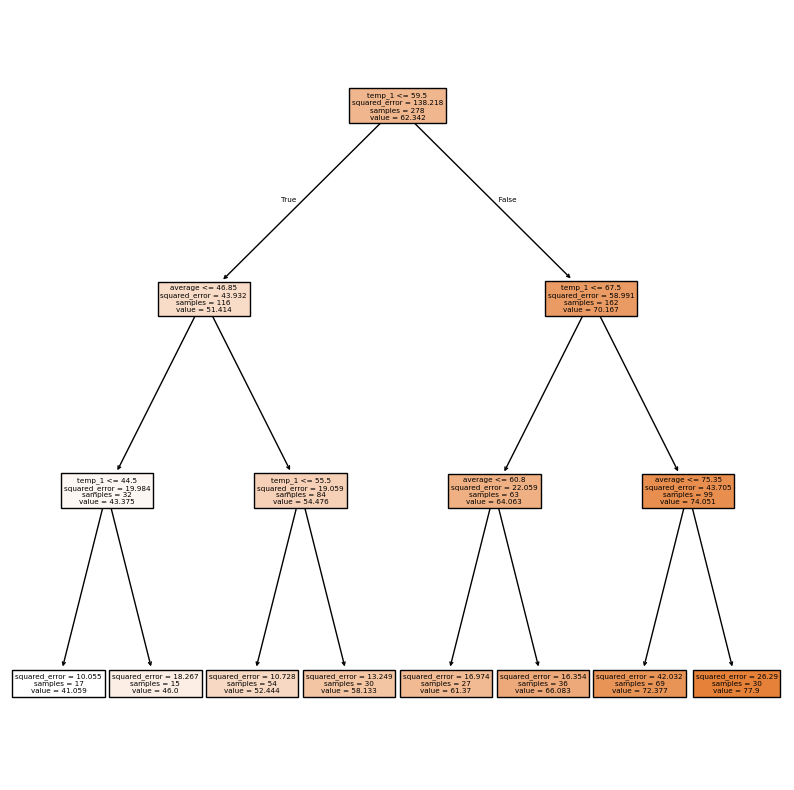

In [26]:
plt.figure(figsize=(10,10))
sklearn.tree.plot_tree(tree_model3,
               feature_names=['month', 'temp_1','temp_2','average'],
                class_names=None,
               filled = True);

### 10. Utiliza un grid search con cross validation para hiperparametrizar tu modelo

In [27]:
from sklearn.model_selection import GridSearchCV

# Grid Search prueba automáticamente todas las combinaciones de parámetros que le pasemos.
# Voy a dejar max depth en 3 y probar 5 y 10

param_grid = {
    'max_depth': [3, 4, 5, 6],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [2, 4], 
    
}

model_grid = DecisionTreeRegressor(random_state=42)

#Creamos el grid search con un cross validation de 5
grid_search = GridSearchCV(
    estimator=model_grid,      # el modelo
    param_grid=param_grid, # las combinaciones a probar
    cv=5,                  # 5 folds de cross validation
    scoring='r2',          # métrica para evaluar (r2 para regresión)
    verbose=1              # para ver el progreso
)

#Ahora lo entrenamos
grid_search.fit (X_train, y_train)

Fitting 5 folds for each of 24 candidates, totalling 120 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeR...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [3, 4, ...], 'min_samples_leaf': [2, 4], 'min_samples_split': [2, 5, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : th

In [28]:
# Sacamos ahora cuales son los parámetros de ese modelo
print(grid_search.best_params_)
#Me saca el R2
print(grid_search.best_score_)
# Mejora poquísimo respecto al anterior

{'max_depth': 4, 'min_samples_leaf': 2, 'min_samples_split': 2}
0.7802477868015265


In [29]:
#Voy a ver todas las métricas. Puede ser que tenga overfitting (llega a minimos muy pequeños de muestras)
y_pred = grid_search.predict (X_test)

In [30]:
print("Train R2:", r2_score (y_train, grid_search.predict(X_train)))
print("Test R2:", r2_score (y_test, y_pred))
print("Train MSE:", mean_squared_error(y_train, grid_search.predict(X_train)))
print("Test MSE:", mean_squared_error(y_test, y_pred))
print("Train MAE:", mean_absolute_error (y_train, grid_search.predict(X_train)))
print("Test MAE:", mean_absolute_error (y_test, y_pred))
print("Train MAPE:", mean_absolute_percentage_error (y_train, grid_search.predict(X_train)))
print("Test MAPE:", mean_absolute_percentage_error (y_test, y_pred))

Train R2: 0.8696610159885674
Test R2: 0.7933173144003249
Train MSE: 18.015161797122133
Test MSE: 28.899469784184447
Train MAE: 3.2845908100090813
Test MAE: 4.0606720597698045
Train MAPE: 0.05233305340901378
Test MAPE: 0.06432799308433161


In [31]:
# tiene toda la pinta de overfitting. hago una última prueba con más rango en los parámetros
from sklearn.model_selection import GridSearchCV

# Grid Search prueba automáticamente todas las combinaciones de parámetros que le pasemos.
# Voy a dejar max depth en 3 y probar 5 y 10

param_grid = {
    'max_depth': range (3, 7),
    'min_samples_split': range (4, 10),
    'min_samples_leaf': range (4, 10), 
    
}

model_grid = DecisionTreeRegressor(random_state=42)

#Creamos el grid search con un cross validation de 5
grid_search = GridSearchCV(
    estimator=model_grid,      # el modelo
    param_grid=param_grid, # las combinaciones a probar
    cv=5,                  # 5 folds de cross validation
    scoring='r2',          # métrica para evaluar (r2 para regresión)
    verbose=1              # para ver el progreso
)

#Ahora lo entrenamos
grid_search.fit (X_train, y_train)

Fitting 5 folds for each of 144 candidates, totalling 720 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeR...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': range(3, 7), 'min_samples_leaf': range(4, 10), 'min_samples_split': range(4, 10)}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- 

In [32]:
print(grid_search.best_params_)
#Me saca el R2
print(grid_search.best_score_)

{'max_depth': 4, 'min_samples_leaf': 8, 'min_samples_split': 4}
0.7966353491151195


In [33]:
#Voy a ver todas las métricas. 
y_pred = grid_search.predict (X_test)
print("Train R2:", r2_score (y_train, grid_search.predict(X_train)))
print("Test R2:", r2_score (y_test, y_pred))
print("Train MSE:", mean_squared_error(y_train, grid_search.predict(X_train)))
print("Test MSE:", mean_squared_error(y_test, y_pred))
print("Train MAE:", mean_absolute_error (y_train, grid_search.predict(X_train)))
print("Test MAE:", mean_absolute_error (y_test, y_pred))
print("Train MAPE:", mean_absolute_percentage_error (y_train, grid_search.predict(X_train)))
print("Test MAPE:", mean_absolute_percentage_error (y_test, y_pred))

Train R2: 0.8609898864267516
Test R2: 0.8020149888256112
Train MSE: 19.213665861003896
Test MSE: 27.68331479511541
Train MAE: 3.3612891715995294
Test MAE: 4.001079430177175
Train MAPE: 0.05360031036327764
Test MAPE: 0.06390895532405284


In [34]:
# ¿por qué el bestscore que me da grid_search es diferente que el que yo calculo? 
# Porque en el caso que me da best_score me hace una media de todos los cross validation que ha hecho con ese modelo. 
# Yo estoy haciéndola sobre una única prueba. Es más fiable la que sale del cross validation.

### 11. Obten el `feature_importances` de cada variable en el último modelo

In [35]:
importancias = grid_search.best_estimator_.feature_importances_
importancias



array([0.        , 0.86801344, 0.        , 0.13198656])

In [36]:
#el segundo parámetro es el que tiene peso realmente (la temperatura del día anterior)

In [37]:
# Convertir a DataFrame para verlo mejor
nombres = X_train.columns
df_importancias = pd.DataFrame({
    'feature': nombres,
    'importancia': importancias
}).sort_values('importancia', ascending=False)

print(df_importancias)

   feature  importancia
1   temp_1     0.868013
3  average     0.131987
0    month     0.000000
2   temp_2     0.000000


### 12. Construye un nuevo modelo `DecisionTreeClassifier` que te clasifique cuando en un día va a hacer una temperatura mayor a 15ºC (59ºF). ¡Deberá tratarse como un problema de **clasificación**! Utiliza un grid search con cross validation y evalúa el mejor modelo.

In [38]:
from sklearn.tree import DecisionTreeClassifier

seattle.head()

,year,month,day,week,temp_2,temp_1,average,actual,friend
0,2016,1,1,Fri,45,45,45.6,45,29
1,2016,1,2,Sat,44,45,45.7,44,61
2,2016,1,3,Sun,45,44,45.8,41,56
3,2016,1,4,Mon,44,41,45.9,40,53
4,2016,1,5,Tues,41,40,46.0,44,41


In [39]:
# La forma primigenia
# if seattle ['actual'] > 59:
#     seattle ['>59'] = True
# else
#     seattle ['>59'] = False

seattle['>59'] = seattle['actual'] > 59

In [40]:
seattle['>59'].value_counts()

>59
True     204
False    144
Name: count, dtype: int64

In [41]:
seattle.columns

Index(['year', 'month', 'day', 'week', 'temp_2', 'temp_1', 'average', 'actual',
       'friend', '>59'],
      dtype='str')

In [49]:
# Puesto que el decisiontree no es muy sensible a colinealidades ni le importan mucho las variables que no tienen relevancia
# esta vez voy a meterlas todas

X = seattle [['year', 'month', 'day', 'temp_2', 'temp_1', 'average', 'friend']]
y = seattle ['>59']

X_train, X_test, y_train, y_test = train_test_split (X, y, test_size=0.2, random_state=42)



In [50]:
param_grid = {
    'max_depth': range (2, 7),
    'min_samples_split': range (4, 10),
    'min_samples_leaf': range (4, 10),    
}

model_grid = DecisionTreeClassifier(random_state=42)

#Creamos el grid search con un cross validation de 5
grid_search = GridSearchCV(
    estimator=model_grid,      # el modelo
    param_grid=param_grid, # las combinaciones a probar
    cv=5,                  # 5 folds de cross validation
    scoring='f1',          # métrica para evaluar (r2 para regresión)
    verbose=1              # para ver el progreso
)

#Ahora lo entrenamos
grid_search.fit (X_train, y_train)

Fitting 5 folds for each of 180 candidates, totalling 900 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': range(2, 7), 'min_samples_leaf': range(4, 10), 'min_samples_split': range(4, 10)}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- 

In [51]:
print(grid_search.best_params_)

{'max_depth': 2, 'min_samples_leaf': 6, 'min_samples_split': 4}


In [52]:
print(grid_search.best_score_)

0.9020076321484879


In [ ]:
# Es una absoluta mierda de predictor. y no entiendo bien por qué. Podría quitar features que se supone que no aplican
# aunque no debería de influir mucho ¿no?
# Estaba midiendo r2 que es un parámetro de regresión!!!!!!!!!!! Hay que medir F1!! (u otra métrica de decisión que sea de clasificación)

# CUIDAUUUUUUU!!!!!!!!!!!!!!!!!!!!!  Estas son las métricas del árbol de regresión!!!!! Necesitaríamos las métricas de decisión: accuracy, precision, curva ROC... 
# y_pred = grid_search.predict (X_test)
# print("Train R2:",  (y_train, grid_search.predict(X_train)))
# print("Test R2:", r2_score (y_test, y_pred))
# print("Train MSE:", mean_squared_error(y_train, grid_search.predict(X_train)))
# print("Test MSE:", mean_squared_error(y_test, y_pred))
# print("Train MAE:", mean_absolute_error (y_train, grid_search.predict(X_train)))
# print("Test MAE:", mean_absolute_error (y_test, y_pred))
# print("Train MAPE:", mean_absolute_percentage_error (y_train, grid_search.predict(X_train)))
# print("Test MAPE:", mean_absolute_percentage_error (y_test, y_pred))

Train R2: 0.6301617709663687
Test R2: 0.5833333333333334
Train MSE: 0.08992805755395683
Test MSE: 0.1
Train MAE: 0.08992805755395683
Test MAE: 0.1
Train MAPE: 356399970511334.2
Test MAPE: 386022825203185.4


In [55]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score

y_pred = grid_search.predict (X_test)
print ('Accuracy:', accuracy_score(y_test, y_pred))
c_matrix = confusion_matrix(y_test, y_pred)
print(c_matrix)

Accuracy: 0.9
[[22  6]
 [ 1 41]]


In [ ]:
# Dudas a resolver cuando corrijamos
# por qué el r2 que me da el best_score es diferente que el que calculo yo?
# cómo funciona internamente el grid_search? me parece imposible que si le paso un rango de opciones y prueba todas con todas
# no encuentre nada mejor
# Prueba todas las combinaciones posibles (todos los parámetros con todos).
# En gridsearch también en los modelos se le pueden pasar una lista y que pruebe distintos modelos con distintos parámetros